### Utils

In [113]:
import time

import matplotlib.pyplot as plt
import numpy as np


In [114]:
def build_element_connectivity_matrix(n_elements):
    connectivity_array = []
    print(
        "\nEnter the end nodes for each element separated by space (for e.g.: '1 2')."
    )
    for i in range(n_elements):
        ends = input(f"Element {i + 1}: ")
        end_nodes_array = [int(end) for end in ends.split(" ")]
        end_nodes_array.sort()
        connectivity_array.append(end_nodes_array)
    return connectivity_array

def build_local_stiffness_matrices_spring(stiffness_vector):
    n_elements = len(stiffness_vector)
    local_stiffness_matrices = []
    for i in range(n_elements):
        local_stiffness_matrices.append(
            np.array(
                [
                    [stiffness_vector[i], -stiffness_vector[i]],
                    [-stiffness_vector[i], stiffness_vector[i]],
                ]
            )
        )
    return np.array(local_stiffness_matrices)


def build_local_stiffness_matrices_bar(A_vector, E_vector, L_vector):
    n_elements = len(A_vector)
    coeff_vector = [A_vector[i] * E_vector[i] / L_vector[i] for i in range(n_elements)]
    local_stiffness_matrices = []
    for i in range(n_elements):
        local_stiffness_matrices.append(
            np.array(
                [
                    [coeff_vector[i], -coeff_vector[i]],
                    [-coeff_vector[i], coeff_vector[i]],
                ]
            )
        )
    return np.array(local_stiffness_matrices)


def build_local_stiffness_matrices_truss(
    A_vector, E_vector, L_vector, theta_deg_vector
):
    n_elements = len(A_vector)
    coeff_vector = [A_vector[i] * E_vector[i] / L_vector[i] for i in range(n_elements)]
    cos_theta = np.cos(np.deg2rad(theta_deg_vector))
    sin_theta = np.sin(np.deg2rad(theta_deg_vector))
    local_stiffness_matrices = []
    for i in range(n_elements):
        local_stiffness_matrices.append(
            np.array(
                [
                    [
                        cos_theta[i] ** 2 * coeff_vector[i],
                        cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        -(cos_theta[i] ** 2) * coeff_vector[i],
                        -cos_theta[i] * sin_theta[i] * coeff_vector[i],
                    ],
                    [
                        cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        sin_theta[i] ** 2 * coeff_vector[i],
                        -cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        -(sin_theta[i] ** 2) * coeff_vector[i],
                    ],
                    [
                        -(cos_theta[i] ** 2) * coeff_vector[i],
                        -cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        cos_theta[i] ** 2 * coeff_vector[i],
                        cos_theta[i] * sin_theta[i] * coeff_vector[i],
                    ],
                    [
                        -cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        -(sin_theta[i] ** 2) * coeff_vector[i],
                        cos_theta[i] * sin_theta[i] * coeff_vector[i],
                        sin_theta[i] ** 2 * coeff_vector[i],
                    ],
                ]
            )
        )

    return np.array(local_stiffness_matrices)


def build_global_stiffness_matrix_from_local_stiffness_matrices(
    n_nodes, local_stiffness_matrices, connectivity_array
):
    n_elements = local_stiffness_matrices.shape[0]
    global_stiffness_matrix = np.zeros((n_nodes, n_nodes))
    for i in range(n_elements):
        nodes = connectivity_array[i]
        for j in range(len(nodes)):
            for k in range(len(nodes)):
                global_stiffness_matrix[nodes[j] - 1, nodes[k] - 1] += (
                    local_stiffness_matrices[i, j, k]
                )
    return global_stiffness_matrix

# Identify unknowns
def identify_unknowns(force_vector, displacement_vector):
    unknown_list = []
    for i in range(len(force_vector)):
        if force_vector[i] == None and displacement_vector[i] == None:
            print(f"Node {i + 1} is an unknown.")
            raise ValueError(
                f"Node {i + 1} has both force and displacement unknown. Please provide at least one of them."
            )
        if force_vector[i] == None:
            unknown_list.append(f"F_{i + 1}")
        elif displacement_vector[i] == None:
            unknown_list.append(f"u_{i + 1}")
    return unknown_list


def build_new_system_equations(
    force_vector, global_stiffness_matrix, displacement_vector, unknown_list
):
    # y = A x
    new_y = np.zeros(len(force_vector))
    new_A = np.zeros((len(force_vector), len(force_vector)))

    for i in range(len(force_vector)):
        if force_vector[i] != None:
            new_y[i] = force_vector[i]
        else:
            new_A[i, i] = 1
        for j in range(len(displacement_vector)):
            if displacement_vector[j] != None:
                new_y[i] -= global_stiffness_matrix[i, j] * displacement_vector[j]
            else:
                new_A[i, j] = global_stiffness_matrix[i, j]
    return new_y, new_A


def FEM_direct_stiffness_method_general(system_txt_file=None, system=None, only_save=False):
    if system is not None and system_txt_file is not None:
        raise ValueError(
            "Please provide either a system txt file or a system object, not both."
        )
    if system_txt_file is not None:
        # Read system from txt file
        try:
            with open(system_txt_file, "r") as f:
                lines = f.readlines()
        except FileNotFoundError:
            print(f"Searching systems folder for '{system_txt_file}'...")
            with open(f"systems/{system_txt_file}", "r") as f:
                lines = f.readlines()
        variables = {}
        for line in lines:
            if line.startswith("##"):
                var_name, var_type = line[2:].strip().split(" ")
                variables[var_name] = {"type": var_type, "value": []}
            elif not line.startswith("#"):
                if var_name in variables:
                    if variables[var_name]["type"] == "int":
                        variables[var_name]["value"] = int(line.strip())
                    elif variables[var_name]["type"] == "float":
                        variables[var_name]["value"] = float(line.strip())
                    elif variables[var_name]["type"] == "str":
                        variables[var_name]["value"] = line.strip()
                    elif variables[var_name]["type"].startswith("list") and line.strip() != "":
                        if variables[var_name]["type"] == "list_of_lists_int":
                            variables[var_name]["value"].append(
                                [int(x) for x in line.strip()[1:-1].split(",")]
                            )
                        elif variables[var_name]["type"] == "list_float":
                            variables[var_name]["value"].append(float(line.strip()))
                        elif variables[var_name]["type"] == "list_float_or_None":
                            value = line.strip()
                            if value == "None":
                                variables[var_name]["value"].append(None)
                            else:
                                variables[var_name]["value"].append(float(value))
        n_elements = variables["n_elements"]["value"]
        n_nodes = variables["n_nodes"]["value"]
        connectivity_array = variables["connectivity_array"]["value"]
        element_type = variables["element_type"]["value"]
        if element_type == "spring":
            stiffness_vector = variables["stiffness_vector"]["value"]
            local_stiffness_matrices = build_local_stiffness_matrices_spring(
                stiffness_vector
            )
        elif element_type == "bar":
            A_vector = variables["A_vector"]["value"]
            E_vector = variables["E_vector"]["value"]
            L_vector = variables["L_vector"]["value"]
            local_stiffness_matrices = build_local_stiffness_matrices_bar(
                A_vector, E_vector, L_vector
            )
        elif element_type == "truss":
            A_vector = variables["A_vector"]["value"]
            E_vector = variables["E_vector"]["value"]
            L_vector = variables["L_vector"]["value"]
            theta_deg_vector = variables["theta_deg_vector"]["value"]
            local_stiffness_matrices = build_local_stiffness_matrices_truss(
                A_vector, E_vector, L_vector, theta_deg_vector
            )
        global_stiffness_matrix = (
            build_global_stiffness_matrix_from_local_stiffness_matrices(
                n_nodes, local_stiffness_matrices, connectivity_array
            )
        )

        force_vector = variables["force_vector"]["value"]
        displacement_vector = variables["displacement_vector"]["value"]
    elif system is not None:
        n_elements = system["n_elements"]
        n_nodes = system["n_nodes"]
        connectivity_array = system["connectivity_array"]
        element_type = system["element_type"]
        if element_type == "spring":
            stiffness_vector = system["stiffness_vector"]
            local_stiffness_matrices = build_local_stiffness_matrices_spring(
                stiffness_vector
            )
        elif element_type == "bar":
            A_vector = system["A_vector"]
            E_vector = system["E_vector"]
            L_vector = system["L_vector"]
            local_stiffness_matrices = build_local_stiffness_matrices_bar(
                A_vector, E_vector, L_vector
            )
        elif element_type == "truss":
            A_vector = system["A_vector"]
            E_vector = system["E_vector"]
            L_vector = system["L_vector"]
            theta_deg_vector = system["theta_deg_vector"]
            local_stiffness_matrices = build_local_stiffness_matrices_truss(
                A_vector, E_vector, L_vector, theta_deg_vector
            )
        global_stiffness_matrix = (
            build_global_stiffness_matrix_from_local_stiffness_matrices(
                n_nodes, local_stiffness_matrices, connectivity_array
            )
        )
        force_vector = system["force_vector"]
        displacement_vector = system["displacement_vector"]
        
    else:
        n_elements = int(input("Enter the number of elements:"))
        n_nodes = int(input("Enter the number of nodes:"))
        connectivity_array = build_element_connectivity_matrix(n_elements)

        # -- Enter element properties
        element_type = input("Enter the element type (spring, bar, truss):")
        if element_type == "spring":
            stiffness_vector = []
            print("\nEnter the stiffness coefficient for each element.")
            for i in range(n_elements):
                stiffness = float(input(f"Element {i + 1}: "))
                stiffness_vector.append(stiffness)
            local_stiffness_matrices = build_local_stiffness_matrices_spring(
                stiffness_vector
            )
        elif element_type == "bar":
            A_vector = []
            E_vector = []
            L_vector = []
            print(
                "\nEnter the cross-sectional area, Young's modulus and length of each element. (e.g.: '1 2 3')"
            )
            for i in range(n_elements):
                A, E, L = input(f"Element {i + 1}: ").split(" ")
                A_vector.append(float(A))
                E_vector.append(float(E))
                L_vector.append(float(L))
            local_stiffness_matrices = build_local_stiffness_matrices_bar(
                A_vector, E_vector, L_vector
            )
        elif element_type == "truss":
            A_vector = []
            E_vector = []
            L_vector = []
            theta_deg_vector = []
            print(
                "\nEnter the cross-sectional area, Young's modulus, length and angle of each element. (e.g.: '1 2 3 4')"
            )
            for i in range(n_elements):
                A, E, L, theta = input(f"Element {i + 1}: ").split(" ")
                A_vector.append(float(A))
                E_vector.append(float(E))
                L_vector.append(float(L))
                theta_deg_vector.append(float(theta))
            local_stiffness_matrices = build_local_stiffness_matrices_truss(
                A_vector, E_vector, L_vector, theta_deg_vector
            )

        # -- Build global stiffness matrix

        global_stiffness_matrix = (
            build_global_stiffness_matrix_from_local_stiffness_matrices(
                n_nodes, local_stiffness_matrices, connectivity_array
            )
        )

        # -- Enter Forces
        force_vector = []
        print(
            "\nEnter the force on each node. Simply press enter (without content) if unknown."
        )
        for i in range(n_nodes):
            force = input(f"Node {i + 1}: ")
            force_vector.append(float(force)) if force != "" else force_vector.append(
                None
            )

        # -- Enter displacements
        displacement_vector = []
        print(
            "\nEnter the displacement on each node. Simply press enter (without content) if unknown."
        )
        for i in range(n_nodes):
            displacement = input(f"Node {i + 1}: ")
            displacement_vector.append(
                float(displacement)
            ) if displacement != "" else displacement_vector.append(None)

    print("\n\n======== SYSTEM DETAILS ========\n")
    print(f"Number of elements: {n_elements}")
    print(f"Number of nodes: {n_nodes}")
    print(
        f"\nConnectivity array: {[f'Element{i + 1}: {connectivity_array[i]}' for i in range(len(connectivity_array))]}"
    )
    for i in range(len(local_stiffness_matrices)):
        print(f"\nElement {i + 1} local stiffness matrix:")
        print(local_stiffness_matrices[i])
    print("\nGlobal stiffness matrix:")
    print(global_stiffness_matrix)

    if system_txt_file is None:
        print("\n\n======== SAVING THE SYSTEM ========\n")
        trial_name = input("Enter a name for the trial (for saving): ")
        if trial_name == "":
            pass
        else:
            with open(f"systems/{trial_name}.txt", "w") as f:
                # header
                f.write(f"# =================== {trial_name} ===================\n")
                f.write("# ----------------------------------------------------\n")
                f.write(
                    "# Lines starting with '#' are comments and will be ignored when reading the file.\n"
                )
                f.write(
                    "# Lines starting with '##' are variable names and types, followed by their values which will be read when reading the file.\n"
                )
                f.write("# In case of values for multiple elements / nodes, enter them one line after another (for e.g.: A_vector, E_vector, L_vector, theta_deg_vector, force_vector, displacement_vector)\n")
                f.write("# In case of multiple values for a single element / node, enter them in a list format (for e.g.: connectivity_array)\n")
                f.write("# ----------------------------------------------------\n")
                f.write("## n_elements int\n")
                f.write(f"{n_elements}\n")
                f.write("## n_nodes int\n")
                f.write(f"{n_nodes}\n")
                f.write("## connectivity_array list_of_lists_int\n")
                for i in range(len(connectivity_array)):
                    f.write(f"{connectivity_array[i]}\n")
                f.write("## element_type str\n")
                f.write(f"{element_type}\n")
                if element_type == "spring":
                    f.write("## stiffness_vector list_float\n")
                    for i in range(len(stiffness_vector)):
                        f.write(f"{stiffness_vector[i]}\n")
                elif element_type == "bar":
                    f.write("## A_vector list_float\n")
                    for i in range(len(A_vector)):
                        f.write(f"{A_vector[i]}\n")
                    f.write("## E_vector list_float\n")
                    for i in range(len(E_vector)):
                        f.write(f"{E_vector[i]}\n")
                    f.write("## L_vector list_float\n")
                    for i in range(len(L_vector)):
                        f.write(f"{L_vector[i]}\n")
                elif element_type == "truss":
                    f.write("## A_vector list_float\n")
                    for i in range(len(A_vector)):
                        f.write(f"{A_vector[i]}\n")
                    f.write("## E_vector list_float\n")
                    for i in range(len(E_vector)):
                        f.write(f"{E_vector[i]}\n")
                    f.write("## L_vector list_float\n")
                    for i in range(len(L_vector)):
                        f.write(f"{L_vector[i]}\n")
                    f.write("## theta_deg_vector list_float\n")
                    for i in range(len(theta_deg_vector)):
                        f.write(f"{theta_deg_vector[i]}\n")
                f.write("## force_vector list_float_or_None\n")
                for i in range(len(force_vector)):
                    f.write(f"{force_vector[i]}\n")
                f.write("## displacement_vector list_float_or_None\n")
                for i in range(len(displacement_vector)):
                    f.write(f"{displacement_vector[i]}\n")
                # footer
                f.write("# ======================= END =======================\n")

    if only_save:
        print("\n\n======== SYSTEM SAVED ========\n")
        return
    print("\n\n======== SOLVING THE SYSTEM ========\n")
    print("(00.00 ms) Compiling unknown list and rearranging equations...")
    start_time = time.time()
    unknown_list = identify_unknowns(force_vector, displacement_vector)
    print(f"({(time.time() - start_time) * 1000:.2f} ms) Unknowns: {unknown_list}")
    new_y, new_A = build_new_system_equations(
        force_vector, global_stiffness_matrix, displacement_vector, unknown_list
    )
    print(f"({(time.time() - start_time) * 1000:.2f} ms) Solving system... ")
    solved_unknown = np.linalg.solve(new_A, new_y)
    print(f"({(time.time() - start_time) * 1000:.2f} ms) Printing results...")
    print("\n\n======== RESULTS ========\n")
    for i in range(len(unknown_list)):
        print(f"\t{unknown_list[i]} = {solved_unknown[i]}")

    return unknown_list, solved_unknown

## Question

In [115]:
# setting the default system to be solved

force_value = 20e3 # N
depth_value = 1 # mm (UNKNOWN d_0)
width_value_left = 60 # mm
width_value_right = 30 # mm
length_value = 500 # mm
E_value = 1 # MPa

def width_at_x(x, width_left=width_value_left, width_right=width_value_right, length=length_value):
    return width_left + (width_right - width_left) * (x / length)

def build_tapered_bar_system(n_elements, force_value=force_value, depth_value=depth_value, width_left=width_value_left, width_right=width_value_right, length=length_value):
    n_nodes = n_elements + 1
    x_values_nodes = np.linspace(0, length_value, n_nodes)
    midpoints = (x_values_nodes[:-1] + x_values_nodes[1:]) / 2
    A_vector = [width_at_x(midpoint) * depth_value for midpoint in midpoints]
    E_vector = [E_value] * n_elements
    L_vector = [length_value / n_elements] * n_elements
    connectivity_array = []
    for i in range(n_elements):
        connectivity_array.append([i + 1, i + 2])
    force_vector = [None] + [0] * (n_nodes - 2) + [force_value]
    displacement_vector = [0] + [None] * n_elements
    system = {
        "n_elements": n_elements,
        "n_nodes": n_elements + 1,
        "connectivity_array": connectivity_array,
        "element_type": "bar",
        "A_vector": A_vector,
        "E_vector": E_vector,
        "L_vector": L_vector,
        "force_vector": force_vector,
        "displacement_vector": displacement_vector,
    }
    return system

#### 1. Tapered bar with different elements

In [116]:
#### Tapered bar with 1 element
unknown_list_1, solved_unknown_1 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=1)
)



======== SYSTEM DETAILS ========

Number of elements: 1
Number of nodes: 2

Connectivity array: ['Element1: [1, 2]']

Element 1 local stiffness matrix:
[[ 0.09 -0.09]
 [-0.09  0.09]]

Global stiffness matrix:
[[ 0.09 -0.09]
 [-0.09  0.09]]


======== SAVING THE SYSTEM ========



======== SOLVING THE SYSTEM ========

(00.00 ms) Compiling unknown list and rearranging equations...
(0.01 ms) Unknowns: ['F_1', 'u_2']
(0.04 ms) Solving system... 
(0.11 ms) Printing results...


======== RESULTS ========

	F_1 = 20000.0
	u_2 = 222222.22222222222


In [117]:
#### Tapered bar with 2 elements
unknown_list_2, solved_unknown_2 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=2)
)



======== SYSTEM DETAILS ========

Number of elements: 2
Number of nodes: 3

Connectivity array: ['Element1: [1, 2]', 'Element2: [2, 3]']

Element 1 local stiffness matrix:
[[ 0.21 -0.21]
 [-0.21  0.21]]

Element 2 local stiffness matrix:
[[ 0.15 -0.15]
 [-0.15  0.15]]

Global stiffness matrix:
[[ 0.21 -0.21  0.  ]
 [-0.21  0.36 -0.15]
 [ 0.   -0.15  0.15]]


======== SAVING THE SYSTEM ========



======== SOLVING THE SYSTEM ========

(00.00 ms) Compiling unknown list and rearranging equations...
(0.01 ms) Unknowns: ['F_1', 'u_2', 'u_3']
(0.04 ms) Solving system... 
(0.09 ms) Printing results...


======== RESULTS ========

	F_1 = 20000.0
	u_2 = 95238.09523809524
	u_3 = 228571.42857142858


In [118]:
#### Tapered bar with 3 elements
unknown_list_3, solved_unknown_3 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=3)
)



======== SYSTEM DETAILS ========

Number of elements: 3
Number of nodes: 4

Connectivity array: ['Element1: [1, 2]', 'Element2: [2, 3]', 'Element3: [3, 4]']

Element 1 local stiffness matrix:
[[ 0.33 -0.33]
 [-0.33  0.33]]

Element 2 local stiffness matrix:
[[ 0.27 -0.27]
 [-0.27  0.27]]

Element 3 local stiffness matrix:
[[ 0.21 -0.21]
 [-0.21  0.21]]

Global stiffness matrix:
[[ 0.33 -0.33  0.    0.  ]
 [-0.33  0.6  -0.27  0.  ]
 [ 0.   -0.27  0.48 -0.21]
 [ 0.    0.   -0.21  0.21]]


======== SAVING THE SYSTEM ========



======== SOLVING THE SYSTEM ========

(00.00 ms) Compiling unknown list and rearranging equations...
(0.01 ms) Unknowns: ['F_1', 'u_2', 'u_3', 'u_4']
(0.05 ms) Solving system... 
(0.11 ms) Printing results...


======== RESULTS ========

	F_1 = 20000.0
	u_2 = 60606.06060606061
	u_3 = 134680.13468013468
	u_4 = 229918.2299182299


In [119]:
#### Tapered bar with 4 elements
unknown_list_4, solved_unknown_4 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=4)
)



======== SYSTEM DETAILS ========

Number of elements: 4
Number of nodes: 5

Connectivity array: ['Element1: [1, 2]', 'Element2: [2, 3]', 'Element3: [3, 4]', 'Element4: [4, 5]']

Element 1 local stiffness matrix:
[[ 0.45 -0.45]
 [-0.45  0.45]]

Element 2 local stiffness matrix:
[[ 0.39 -0.39]
 [-0.39  0.39]]

Element 3 local stiffness matrix:
[[ 0.33 -0.33]
 [-0.33  0.33]]

Element 4 local stiffness matrix:
[[ 0.27 -0.27]
 [-0.27  0.27]]

Global stiffness matrix:
[[ 0.45 -0.45  0.    0.    0.  ]
 [-0.45  0.84 -0.39  0.    0.  ]
 [ 0.   -0.39  0.72 -0.33  0.  ]
 [ 0.    0.   -0.33  0.6  -0.27]
 [ 0.    0.    0.   -0.27  0.27]]


======== SAVING THE SYSTEM ========



======== SOLVING THE SYSTEM ========

(00.00 ms) Compiling unknown list and rearranging equations...
(0.01 ms) Unknowns: ['F_1', 'u_2', 'u_3', 'u_4', 'u_5']
(0.04 ms) Solving system... 
(0.10 ms) Printing results...


======== RESULTS ========

	F_1 = 19999.999999999993
	u_2 = 44444.44444444442
	u_3 = 95726.49572649568
	u_

In [120]:
# tapered_bar with 8 elements
unknown_list_8, solved_unknown_8 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=8)
)



======== SYSTEM DETAILS ========

Number of elements: 8
Number of nodes: 9

Connectivity array: ['Element1: [1, 2]', 'Element2: [2, 3]', 'Element3: [3, 4]', 'Element4: [4, 5]', 'Element5: [5, 6]', 'Element6: [6, 7]', 'Element7: [7, 8]', 'Element8: [8, 9]']

Element 1 local stiffness matrix:
[[ 0.93 -0.93]
 [-0.93  0.93]]

Element 2 local stiffness matrix:
[[ 0.87 -0.87]
 [-0.87  0.87]]

Element 3 local stiffness matrix:
[[ 0.81 -0.81]
 [-0.81  0.81]]

Element 4 local stiffness matrix:
[[ 0.75 -0.75]
 [-0.75  0.75]]

Element 5 local stiffness matrix:
[[ 0.69 -0.69]
 [-0.69  0.69]]

Element 6 local stiffness matrix:
[[ 0.63 -0.63]
 [-0.63  0.63]]

Element 7 local stiffness matrix:
[[ 0.57 -0.57]
 [-0.57  0.57]]

Element 8 local stiffness matrix:
[[ 0.51 -0.51]
 [-0.51  0.51]]

Global stiffness matrix:
[[ 0.93 -0.93  0.    0.    0.    0.    0.    0.    0.  ]
 [-0.93  1.8  -0.87  0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.87  1.68 -0.81  0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0

In [121]:
# tapered_bar with 32 elements
unknown_list_32, solved_unknown_32 = FEM_direct_stiffness_method_general(
    system=build_tapered_bar_system(n_elements=32)
)



======== SYSTEM DETAILS ========

Number of elements: 32
Number of nodes: 33

Connectivity array: ['Element1: [1, 2]', 'Element2: [2, 3]', 'Element3: [3, 4]', 'Element4: [4, 5]', 'Element5: [5, 6]', 'Element6: [6, 7]', 'Element7: [7, 8]', 'Element8: [8, 9]', 'Element9: [9, 10]', 'Element10: [10, 11]', 'Element11: [11, 12]', 'Element12: [12, 13]', 'Element13: [13, 14]', 'Element14: [14, 15]', 'Element15: [15, 16]', 'Element16: [16, 17]', 'Element17: [17, 18]', 'Element18: [18, 19]', 'Element19: [19, 20]', 'Element20: [20, 21]', 'Element21: [21, 22]', 'Element22: [22, 23]', 'Element23: [23, 24]', 'Element24: [24, 25]', 'Element25: [25, 26]', 'Element26: [26, 27]', 'Element27: [27, 28]', 'Element28: [28, 29]', 'Element29: [29, 30]', 'Element30: [30, 31]', 'Element31: [31, 32]', 'Element32: [32, 33]']

Element 1 local stiffness matrix:
[[ 3.81 -3.81]
 [-3.81  3.81]]

Element 2 local stiffness matrix:
[[ 3.75 -3.75]
 [-3.75  3.75]]

Element 3 local stiffness matrix:
[[ 3.69 -3.69]
 [-3.69

#### 1. End displacement for different number of elements

In [122]:
n_elements_list = [1, 2, 3, 4, 8]
right_displacements = [
    solved_unknown_1[-1],
    solved_unknown_2[-1],
    solved_unknown_3[-1],
    solved_unknown_4[-1],
    solved_unknown_8[-1]
]

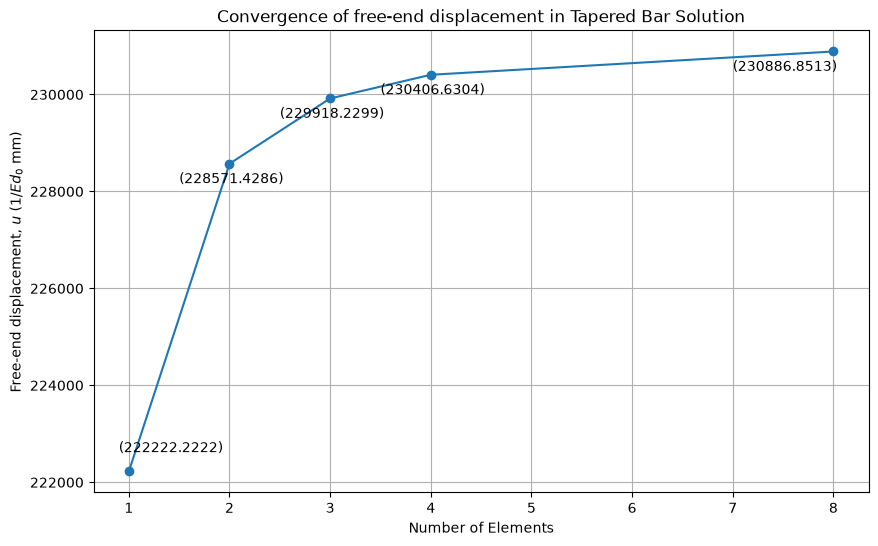

In [123]:
# plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_elements_list, right_displacements, 'o-')
plt.xlabel('Number of Elements')
plt.ylabel(r'Free-end displacement, $u$ ($1 / Ed_0$ mm)')
plt.title('Convergence of free-end displacement in Tapered Bar Solution')
x_align_corrections = [-0.1, -0.5, -0.5, -0.5, -1]
y_align_corrections = [400, -400, -400, -400, -400]  # Adjust these values as needed for better alignment
# annotate the last point
for i in range(len(n_elements_list)):
    plt.annotate(
        f"({right_displacements[i]:.4f})",
        xy=(n_elements_list[i], right_displacements[i]),
        xytext=(n_elements_list[i] + x_align_corrections[i], right_displacements[i] + y_align_corrections[i]),
        fontsize=10,
        color='black'
    )
plt.savefig('lab_1_1.png', dpi=300, bbox_inches='tight')
plt.grid()
plt.show()

#### 2.2 and 2.3. Displacement comparison for different number of elements

In [124]:
n_elements_list = [1, 2, 4, 8, 32]
x_values_nodes_list = [np.linspace(0, length_value, n + 1) for n in n_elements_list]
displacement_values_list = [
    [0] + list(solved_unknown_1[1:]),
    [0] + list(solved_unknown_2[1:]),
    [0] + list(solved_unknown_4[1:]),
    [0] + list(solved_unknown_8[1:]),
    [0] + list(solved_unknown_32[1:])
]


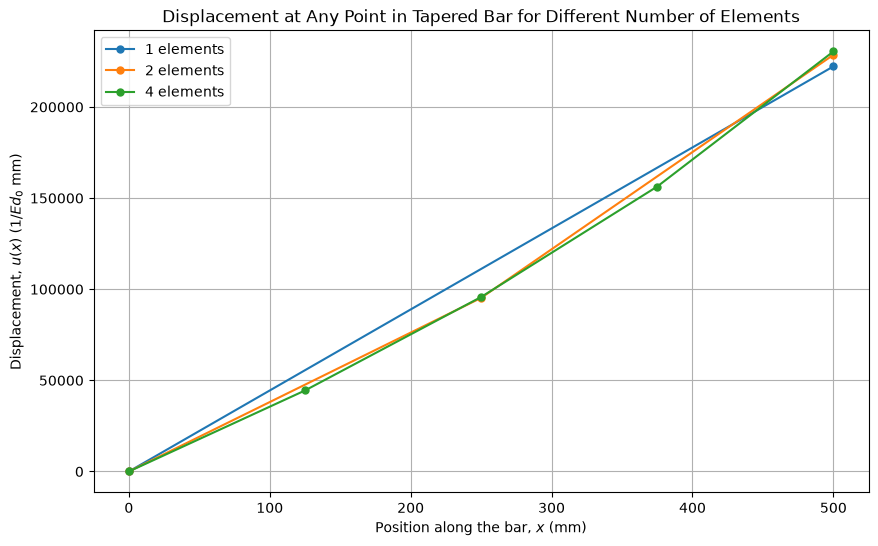

In [125]:
# Plotting the results
plt.figure(figsize=(10, 6))
marker_sizes = [5, 5, 5, 3]  # Adjust marker sizes for each line
for i in range(len(n_elements_list)):
    if i == len(n_elements_list) - 2:
        break  # Skip the last element (8 elements) for plotting
    plt.plot(
        x_values_nodes_list[i],
        displacement_values_list[i],
        marker="o",
        markersize=marker_sizes[i],
        label=f"{n_elements_list[i]} elements",
    )
plt.xlabel(r"Position along the bar, $x$ (mm)")
plt.ylabel(r"Displacement, $u(x)$ ($1 / Ed_0$ mm)")
plt.title("Displacement at Any Point in Tapered Bar for Different Number of Elements")
plt.legend()
plt.grid(True)
plt.savefig('lab_1_2_c.png', dpi=300, bbox_inches='tight')
plt.show()

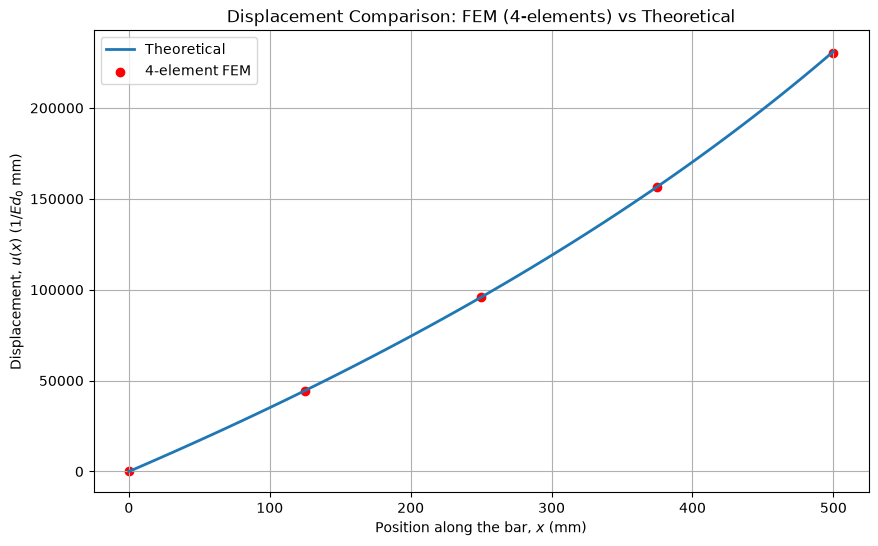

In [126]:
def ideal_displacement_fn(x, force=force_value, depth=depth_value, L=length_value, E=E_value, left_width=width_value_left, right_width=width_value_right):
    return (force * L / (E * depth * (right_width - left_width))) * np.log((left_width + (right_width - left_width) * (x / L)) / left_width)

# Plotting the results Ideal vs 4 elements
plt.figure(figsize=(10, 6))
x_values_ideal = np.linspace(0, length_value, 100)
plt.plot(x_values_ideal, ideal_displacement_fn(x_values_ideal), label="Theoretical", linewidth=2)
plt.scatter(x_values_nodes_list[2], displacement_values_list[2], marker="o", c='red', label="4-element FEM")
plt.xlabel(r"Position along the bar, $x$ (mm)")
plt.ylabel(r"Displacement, $u(x)$ ($1 / Ed_0$ mm)")
plt.title("Displacement Comparison: FEM (4-elements) vs Theoretical")
plt.legend()
plt.grid(True)
plt.savefig('lab_1_2_c_2.png', dpi=300, bbox_inches='tight')
plt.show()

#### 3.1. Stress at each element for 4 elements

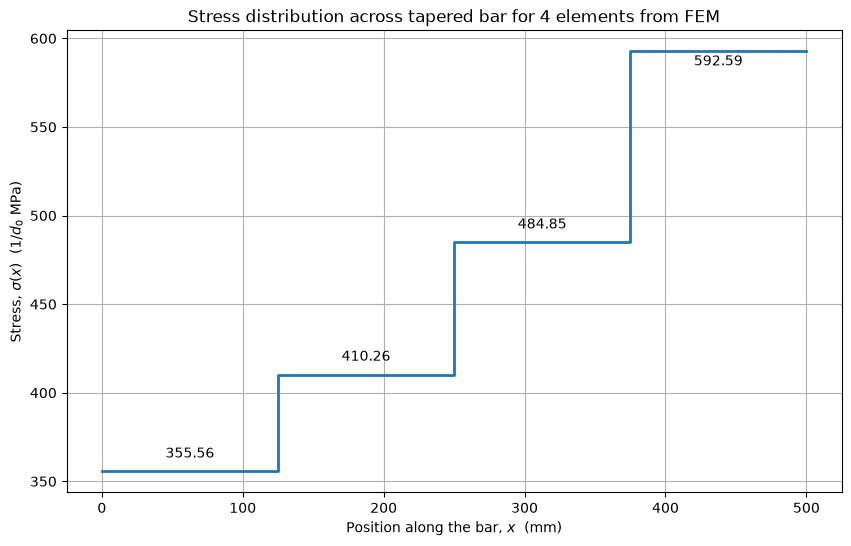

In [127]:
def calc_strain_element(delta, length):
    return delta / length

E_4el = E_value  # Young's modulus in MPa
L_4el = length_value / 4  # Length of each element for 4 elements
node_displacements_4el = [0] + list(solved_unknown_4[1:])  # Displacement at each node for 4 elements
delta_4el = [node_displacements_4el[i + 1] - node_displacements_4el[i] for i in range(len(node_displacements_4el) - 1)]  # Change in displacement for each element
strain_values_4el = [calc_strain_element(delta_4el[i], L_4el) for i in range(len(delta_4el))]
stress_values_4el = [E_4el * strain_values_4el[i] for i in range(len(strain_values_4el))]
mid_x_values_4el = [(x_values_nodes_list[2][i] + x_values_nodes_list[2][i + 1]) / 2 for i in range(len(x_values_nodes_list[2]) - 1)]

#add end points for plotting
mid_x_values_4el = [0] + mid_x_values_4el + [length_value]
stress_values_4el = [stress_values_4el[0]] + stress_values_4el + [stress_values_4el[-1]]
# Plotting the results
plt.figure(figsize=(10, 6))
# plotting the stress values for 4 elements
plt.step(mid_x_values_4el, stress_values_4el, where='mid', label="Stress values for 4 elements", linewidth=2)
# annotating the stress values on the plot
x_align_corrections = [0, 0, 0, 0]  # Adjust these values as needed for better alignment
y_align_corrections = [10, 10, 10, -10]  # Adjust these values as needed for better alignment
for j in range(len(x_align_corrections)):
    plt.annotate(f"{stress_values_4el[j+1]:.2f}", (mid_x_values_4el[j+1], stress_values_4el[j+1]), textcoords="offset points", xytext=(x_align_corrections[j], y_align_corrections[j]), ha='center')
# only integers on the x-axis
plt.xlabel("Position along the bar, $x$  (mm)")
plt.ylabel(r"Stress, $\sigma(x)$  ($1/d_0$ MPa)")
plt.title("Stress distribution across tapered bar for 4 elements from FEM")
# plt.legend()
plt.grid(True)
plt.savefig('lab_1_3_a.png', dpi=300, bbox_inches='tight')
plt.show()

In [130]:
E_32el = E_value  # Young's modulus in MPa
L_32el = length_value / 32  # Length of each element for 32 elements
node_displacements_32el = [0] + list(solved_unknown_32[1:])  # Displacement at each node for 32 elements
delta_32el = [node_displacements_32el[i + 1] - node_displacements_32el[i] for i in range(len(node_displacements_32el) - 1)]  # Change in displacement for each element
strain_values_32el = [calc_strain_element(delta_32el[i], L_32el) for i in range(len(delta_32el))]
stress_values_32el = [E_32el * strain_values_32el[i] for i in range(len(strain_values_32el))]

# add end points for plotting
mid_x_values_32el = [0] + [(x_values_nodes_list[4][i] + x_values_nodes_list[4][i + 1]) / 2 for i in range(len(x_values_nodes_list[4]) - 1)] + [length_value]
stress_values_32el = [stress_values_32el[0]] + stress_values_32el + [stress_values_32el[-1]]

#### 3.3. Stress comparison theory vs 4 elements vs 32 elements

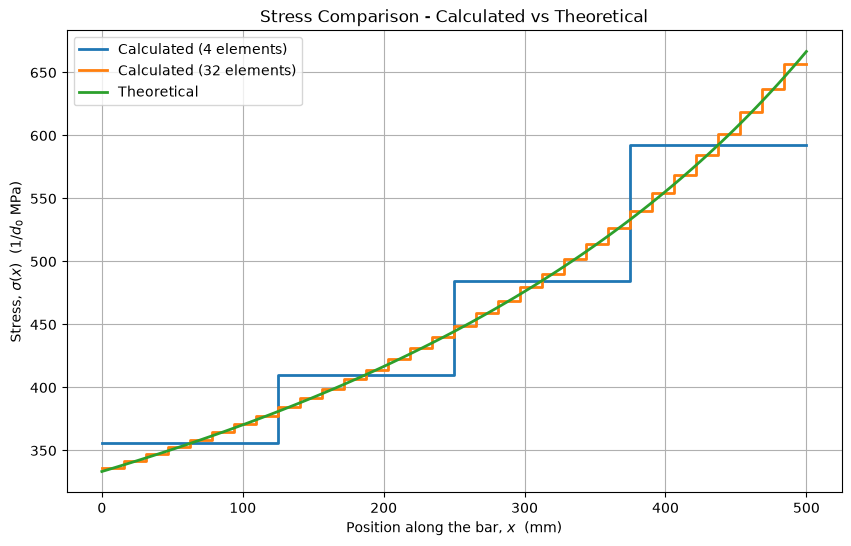

In [132]:
def ideal_stress_fn(x, force=force_value, depth=depth_value, L=length_value, left_width=width_value_left, right_width=width_value_right):
    return (force / depth) * (1 / (left_width + (right_width - left_width) * (x / L)))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.step(mid_x_values_4el, stress_values_4el, where='mid', label="Calculated (4 elements)", linewidth=2)
plt.step(mid_x_values_32el, stress_values_32el, where='mid', label="Calculated (32 elements)", linewidth=2)
plt.plot(
    np.linspace(0, length_value, 100),
    ideal_stress_fn(np.linspace(0, length_value, 100)),
    label="Theoretical",
    linewidth=2
)
# annotating the stress values on the plot
# for j in range(len(stress_values)):
#     plt.annotate(f"{stress_values[j]:.2f}", (j + 1, stress_values[j]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel(r"Position along the bar, $x$  (mm)")
plt.ylabel(r"Stress, $\sigma(x)$  ($1/d_0$ MPa)")
plt.title("Stress Comparison - Calculated vs Theoretical")
plt.legend()
plt.grid(True)
plt.savefig('lab_1_3_c.png', dpi=300, bbox_inches='tight')
plt.show()